# Задача 6: Резонансная кривая при нелинейном взаимодействии пучок-частица

**Условие:**
Качественно нарисуйте ожидаемую резонансную кривую, предположив, что нелинейность колебаний возникает из-за нелинейной зависимости силы взаимодействия пучка и частицы от координаты (возьмите одномерную кривую $\Delta \nu_b(a)$).

**Физический анализ:**

1.  **Сдвиг частоты от амплитуды (Detuning with amplitude):**
    Сила взаимодействия частицы с встречным пучком (beam-beam interaction) нелинейна. Для гауссова пучка сила $F(r) \propto \frac{1}{r}(1 - e^{-r^2/2\sigma^2})$.
    *   При малых амплитудах ($a \ll \sigma$) сила линейна, сдвиг частоты максимален и равен параметру сдвига пучка $\xi$ (beam-beam parameter).
        $$ \nu(a \to 0) = \nu_0 + \xi $$
    *   При больших амплитудах ($a \gg \sigma$) сила убывает, и сдвиг частоты стремится к нулю.
        $$ \nu(a \to \infty) = \nu_0 $$
    
    Таким образом, собственная частота колебаний $\nu_{osc}(a)$ монотонно уменьшается (если $\xi > 0$) или увеличивается (если $\xi < 0$) от значения $\nu_0 + \xi$ к значению $\nu_0$ при росте амплитуды. Это поведение "мягкой" пружины (softening spring) относительно возмущенной частоты.

2.  **Резонансная кривая:**
    Резонансная кривая показывает зависимость установившейся амплитуды колебаний $A$ от частоты внешней вынуждающей силы $\nu_{drive}$.
    *   В линейной системе резонанс происходит строго на частоте $\nu_0$.
    *   В нелинейной системе резонанс происходит, когда частота драйвера совпадает с собственной частотой, зависящей от амплитуды: $\nu_{drive} \approx \nu_{osc}(A)$.
    
    Поскольку $\nu_{osc}(A)$ меняется от $\nu_0+\xi$ до $\nu_0$, вершина резонансной кривой "загибается" (tilt) в сторону частоты $\nu_0$.
    
    *   Если $\xi > 0$ (фокусировка, например, $p\bar{p}$), кривая наклонена влево (в сторону низких частот).
    *   Если $\xi < 0$ (дефокусировка, например, $pp$), кривая наклонена вправо (в сторону высоких частот).

**Построение:**
Мы построим "скелетную кривую" (backbone curve), которая представляет собой зависимость $A(\nu_{osc})$, и вокруг нее схематично изобразим резонансный отклик.

<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\D'
<>:94: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\D'
<>:94: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_34072/46544964.py:46: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_xlabel('Амплитуда $A / \sigma$')
/tmp/ipykernel_34072/46544964.py:47: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel('$\Delta \\nu(A) / \\xi$')
/tmp/ipykernel_34072/46544964.py:94: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_ylabel('Амплитуда $A / \sigma$')
/tmp/ipykernel_34072/46544964.py:73: RuntimeWarning: divide by zero encountered in divide
  valid_indices = np.where((F/amplitudes)**2 > gamma_damping**2)[0]


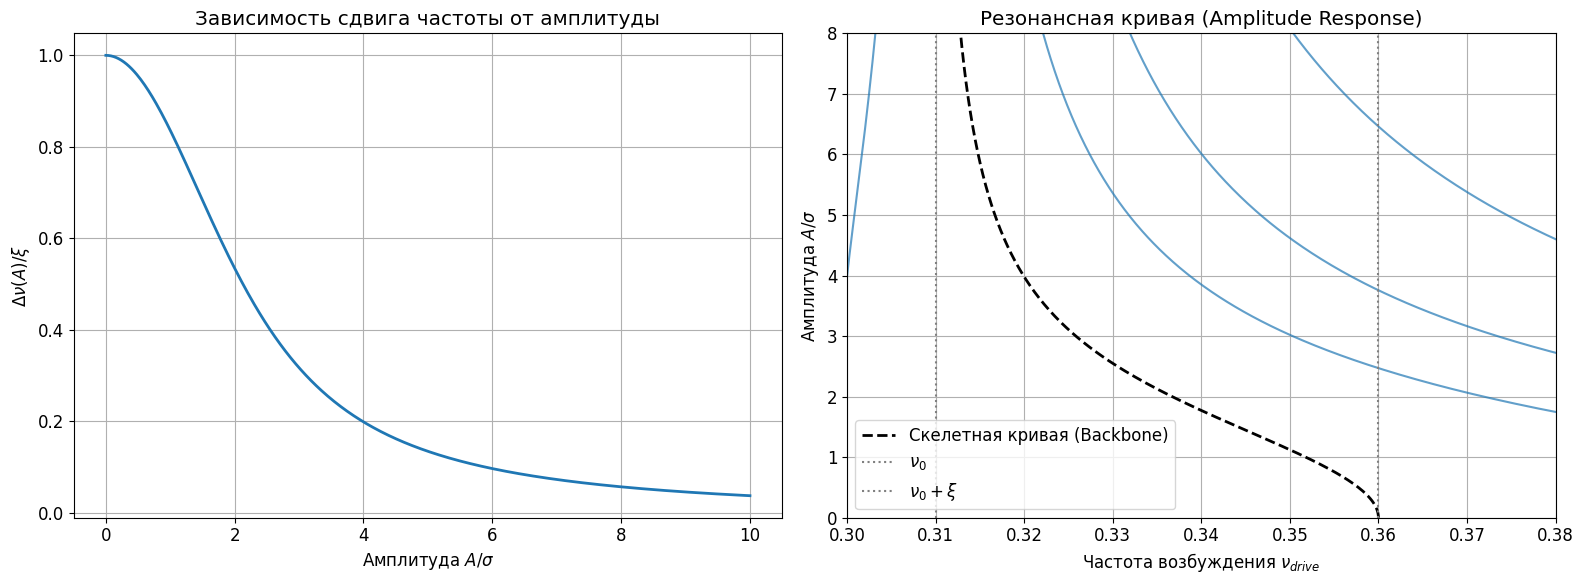

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def beam_beam_tune_shift_1d(amplitude, sigma, xi):
    """
    Вычисляет сдвиг частоты для 1D гауссова пучка.
    Delta_nu / xi = (2/J) * (1 - exp(-J/2)*I0(J/2))
    где J = (amplitude / sigma)^2 / 2
    """
    # Избегаем деления на ноль
    amp = np.array(amplitude)
    J = (amp**2) / (2 * sigma**2)
    
    # Для малых J разложение: (2/J)*(1 - (1-J/2)(1+J^2/16...)) approx 1
    
    with np.errstate(divide='ignore', invalid='ignore'):
        factor = (2.0 / J) * (1.0 - np.exp(-J/2.0) * i0(J/2.0))
    
    factor = np.where(J < 1e-5, 1.0, factor)
    
    return xi * factor

# Параметры
sigma = 1.0
xi = 0.05 # Положительный сдвиг (фокусировка)
nu_0 = 0.31

# Амплитуды
amplitudes = np.linspace(0, 10*sigma, 500)

# Зависимость собственной частоты от амплитуды (Backbone curve)
nu_osc = nu_0 + beam_beam_tune_shift_1d(amplitudes, sigma, xi)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. График сдвига частоты от амплитуды
ax1.plot(amplitudes/sigma, (nu_osc - nu_0)/xi, linewidth=2)
ax1.set_title('Зависимость сдвига частоты от амплитуды')
ax1.set_xlabel('Амплитуда $A / \sigma$')
ax1.set_ylabel('$\Delta \\nu(A) / \\xi$')
ax1.grid(True)

# 2. Резонансная кривая (качественно)
# Backbone curve: Frequency(Amplitude) -> Amplitude(Frequency)
ax2.plot(nu_osc, amplitudes/sigma, 'k--', linewidth=2, label='Скелетная кривая (Backbone)')

# Рисуем схематичные резонансные кривые для разных уровней возбуждения
# Для качественного построения используем Лоренцев профиль, смещенный на backbone
drive_freqs = np.linspace(nu_0 - 0.01, nu_0 + xi + 0.02, 1000)

# Простая модель: ((nu^2 - nu_osc(A)^2)^2 + (gamma*nu)^2)^(-1/2) = F_drive
# Это неявное уравнение. Для качественного рисунка просто нарисуем "тень" вокруг backbone.
# Или решим уравнение A * sqrt((nu_d^2 - nu_osc(A)^2)^2 + g^2) = F
# g - затухание

gamma_damping = 0.002
F_drives = [0.05, 0.1, 0.2] # Разные силы возбуждения

for F in F_drives:
    # Решаем уравнение для каждого nu_drive, чтобы найти A
    # Это сложно, проще наоборот: для каждого A найти nu_drive
    # (nu_d^2 - nu_osc^2)^2 = (F/A)^2 - g^2
    # nu_d^2 = nu_osc^2 +/- sqrt((F/A)^2 - g^2)
    
    # Фильтруем A, где подкоренное выражение положительно
    valid_indices = np.where((F/amplitudes)**2 > gamma_damping**2)[0]
    # Исключаем A=0
    valid_indices = valid_indices[valid_indices > 0]
    
    amps_valid = amplitudes[valid_indices]
    nu_sq_osc = nu_osc[valid_indices]**2
    term = np.sqrt((F/amps_valid)**2 - gamma_damping**2)
    
    nu_d_1 = np.sqrt(np.maximum(0, nu_sq_osc - term))
    nu_d_2 = np.sqrt(nu_sq_osc + term)
    
    # Собираем точки для построения
    # Кривая идет вверх по nu_d_1 и вниз по nu_d_2
    # Но это для фиксированного A.
    # На графике A(nu) это выглядит как "язык".
    
    ax2.plot(nu_d_1, amps_valid/sigma, color='tab:blue', alpha=0.7)
    ax2.plot(nu_d_2, amps_valid/sigma, color='tab:blue', alpha=0.7)

ax2.set_title('Резонансная кривая (Amplitude Response)')
ax2.set_xlabel('Частота возбуждения $\\nu_{drive}$')
ax2.set_ylabel('Амплитуда $A / \sigma$')
ax2.set_xlim(nu_0 - 0.01, nu_0 + xi + 0.02)
ax2.set_ylim(0, 8)
ax2.axvline(nu_0, color='gray', linestyle=':', label='$\\nu_0$')
ax2.axvline(nu_0 + xi, color='gray', linestyle=':', label='$\\nu_0 + \\xi$')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()